In [7]:
# import 
# import wget # download files
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler # customize the training
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
import warnings
warnings.filterwarnings("ignore") 

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Load Data

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we're going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants and bees.
There are 75 validation images for each class. Usually, this is a very
small dataset to generalize upon, if trained from scratch. Since we
are using transfer learning, we should be able to generalize reasonably
well.

This dataset is a very small subset of imagenet. 
Most of the sites don't have certification: `--no-check-certificate`

The date also available for manual download from
   `https://download.pytorch.org/tutorial/hymenoptera_data.zip`
   or 
   `https://www.kaggle.com/datasets/ajayrana/hymenoptera-data/`
   and extract it to the current directory.
 

Unzipping the data to the data folder:
`unzip hymenoptera_data.zip -d data`

The easiest way to get a testset is to create a `test` folder manualy move some image ther from the validationset and testset. 


In [4]:
# !wget https://download.pytorch.org/tutorial/hymenoptera_data.zip --no-check-certificate
# !unzip hymenoptera_data.zip -d data

## Data augmentation 
- Augmentation and normalization for training - https://pytorch.org/vision/stable/transforms.html and https://pytorch.org/vision/main/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py
- Normalization for validation

In [10]:
Batch_size=64;

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=(5, 50), translate=(0.1, 0.3), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=Batch_size, shuffle=True, num_workers=4) for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(class_names)



['ants', 'bees']


### Visualize a few images

Let's visualize a few training images so as to understand the data
augmentations. Decrease the bach size for better visualisation.



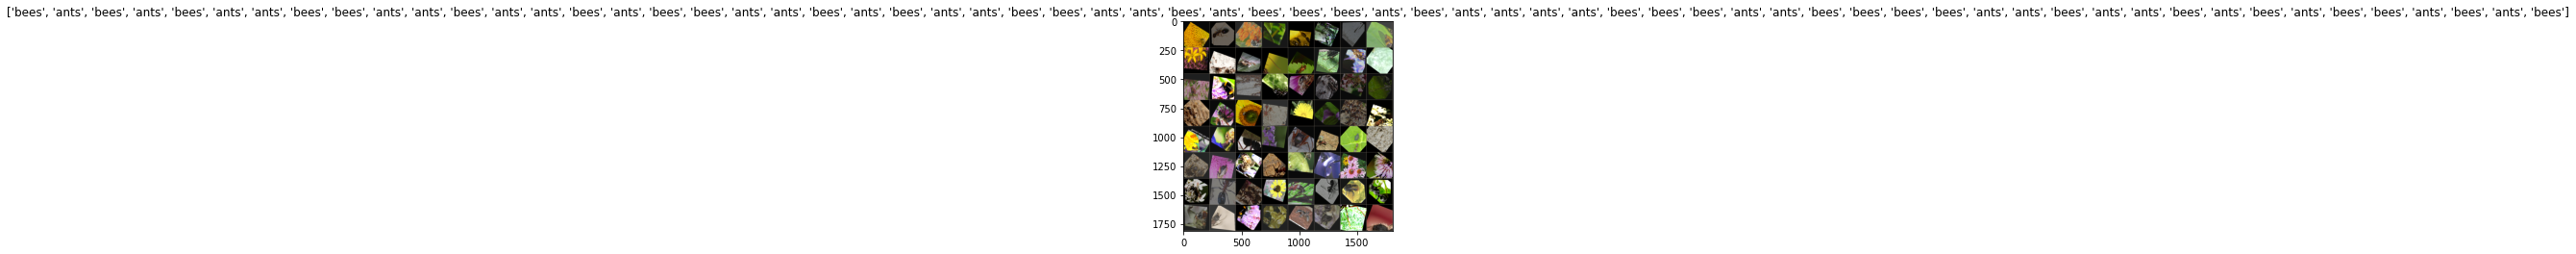

In [11]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

Training the model
------------------

Now, let's write a general function to train a model. Here, we will
illustrate:

-  Scheduling the learning rate
-  Saving the best model

In the following, parameter ``scheduler`` is an LR scheduler object from
``torch.optim.lr_scheduler``.



In [12]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    val_acc_h=[]
    train_acc_h=[]
    for epoch in range(num_epochs):
      
            
        print('Epoch {}/{} LR {:.6f}'.format(epoch, num_epochs - 1, scheduler.get_last_lr()[0]))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()
                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))
            if phase == 'train':
                train_acc_h.append(epoch_acc)
            # deep copy the model
            if phase == 'val':
                val_acc_h.append(epoch_acc)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                

        print('Test started')
    phase == 'test'
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    for inputs, labels in dataloaders[phase]:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        test_loss = running_loss / dataset_sizes[phase]
        test_acc = running_corrects.double() / dataset_sizes[phase]
        
    time_elapsed = time.time() - since
    print('Training and testing complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    print('Test Acc: {:4f}'.format(test_acc))
    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, val_acc_h, train_acc_h, test_acc

### Visualizing the model predictions

Generic function to display predictions for a few images




In [13]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                fig = plt.figure(figsize=(10,10))
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Model overview: **ResNet18**

**ResNet18 Architecture**

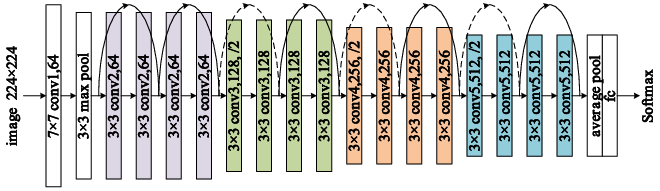

In [14]:
model = models.resnet18()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Train the ConvNet from scratch

Everything from scratch - convolutional and fully connected

In [15]:
model = models.resnet18()
numrs = model.fc.in_features
# Here the size of the output is 2.
model.fc = nn.Linear(numrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [16]:
model, val_acc_h, train_acc_h, test_acc = train_model(model, criterion, optimizer, exp_lr_scheduler,
                       num_epochs=10)

Epoch 0/9 LR 0.000100
----------


train Loss: 0.7520 Acc: 0.4906
val Loss: 0.6995 Acc: 0.4463
Test started
Epoch 1/9 LR 0.000100
----------
train Loss: 0.6856 Acc: 0.5991
val Loss: 0.7086 Acc: 0.5041
Test started
Epoch 2/9 LR 0.000100
----------
train Loss: 0.7041 Acc: 0.5755
val Loss: 0.7139 Acc: 0.3967
Test started
Epoch 3/9 LR 0.000100
----------
train Loss: 0.6513 Acc: 0.6274
val Loss: 0.7001 Acc: 0.6033
Test started
Epoch 4/9 LR 0.000100
----------
train Loss: 0.6898 Acc: 0.5566
val Loss: 0.8082 Acc: 0.4298
Test started
Epoch 5/9 LR 0.000100
----------
train Loss: 0.6945 Acc: 0.5849
val Loss: 0.6925 Acc: 0.5868
Test started
Epoch 6/9 LR 0.000100
----------
train Loss: 0.6389 Acc: 0.5991
val Loss: 0.6662 Acc: 0.6446
Test started
Epoch 7/9 LR 0.000010
----------
train Loss: 0.6058 Acc: 0.6698
val Loss: 0.6383 Acc: 0.6529
Test started
Epoch 8/9 LR 0.000010
----------
train Loss: 0.6075 Acc: 0.6509
val Loss: 0.6352 Acc: 0.6198
Test started
Epoch 9/9 LR 0.000010
----------
train Loss: 0.6116 Acc: 0.6321
val Loss: 0.646

In [17]:
def plot_acc(train_acc_h,val_acc_h, test_acc): 
    plt.figure(figsize=(10,6))
    plt.xlabel('Iteration')
    plt.ylabel('Acc')
    plt.title('Acc by Iteration')
    plt.plot(torch.tensor(train_acc_h, device = 'cpu')*100)
    plt.plot(torch.tensor(val_acc_h, device = 'cpu')*100)
    plt.plot(torch.tensor(test_acc, device = 'cpu')*100*np.ones(len(val_acc_h)))
    plt.ylim((50,100))
    plt.legend(['train', 'valid', 'test'])

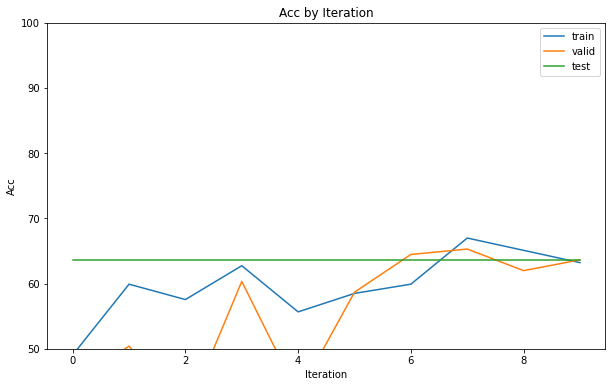

In [18]:
plot_acc(train_acc_h,val_acc_h, test_acc)

# Finetuning the ConvNet




Load a pretrained model and reset final fully connected layer.
we're training the whole network again WITH pretrained weights - Convolution and Fully Connected

In [19]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss() # BinaryCrossEntropyLoss

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/karcagtamas/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100.0%


Train and evaluate

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [20]:
model_ft, val_acc_h, train_acc_h, test_acc = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=10)

Epoch 0/9 LR 0.001000
----------


train Loss: 0.7000 Acc: 0.5708
val Loss: 0.5444 Acc: 0.7107
Test started
Epoch 1/9 LR 0.001000
----------
train Loss: 0.6520 Acc: 0.6038
val Loss: 0.4555 Acc: 0.8264
Test started
Epoch 2/9 LR 0.001000
----------
train Loss: 0.5902 Acc: 0.6745
val Loss: 0.4433 Acc: 0.8182
Test started
Epoch 3/9 LR 0.001000
----------
train Loss: 0.5528 Acc: 0.7170
val Loss: 0.3455 Acc: 0.9174
Test started
Epoch 4/9 LR 0.001000
----------
train Loss: 0.4452 Acc: 0.8538
val Loss: 0.2691 Acc: 0.9174
Test started
Epoch 5/9 LR 0.001000
----------
train Loss: 0.4109 Acc: 0.8113
val Loss: 0.2406 Acc: 0.9256
Test started
Epoch 6/9 LR 0.001000
----------
train Loss: 0.3781 Acc: 0.8538
val Loss: 0.2144 Acc: 0.9587
Test started
Epoch 7/9 LR 0.000100
----------
train Loss: 0.3298 Acc: 0.8821
val Loss: 0.2192 Acc: 0.9587
Test started
Epoch 8/9 LR 0.000100
----------
train Loss: 0.3639 Acc: 0.8443
val Loss: 0.2168 Acc: 0.9587
Test started
Epoch 9/9 LR 0.000100
----------
train Loss: 0.3012 Acc: 0.9292
val Loss: 0.219

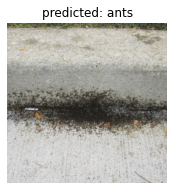

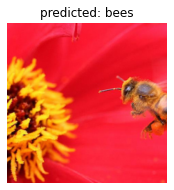

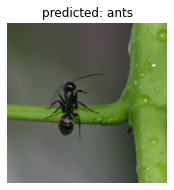

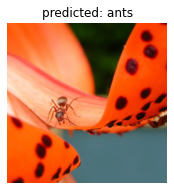

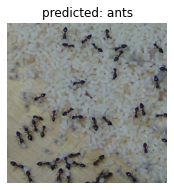

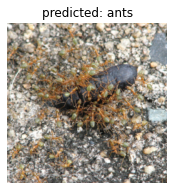

In [21]:
visualize_model(model_ft)

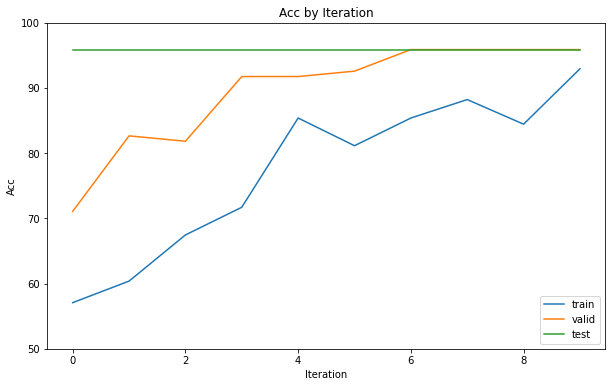

In [22]:
plot_acc(train_acc_h,val_acc_h, test_acc)

# ConvNet as fixed feature extractor - Transfer Learning!






Here, we need to freeze all the network except the final layer. We need
to set ``requires_grad == False`` to freeze the parameters so that the
gradients are not computed in ``backward()``.

You can read more about this in the documentation
`here <https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward>`__.

In [23]:
model_conv = torchvision.models.resnet18(pretrained=True) ## PRETRAINED!!!
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Train and evaluate

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don't need to be computed for most of the
network. However, forward does need to be computed.




In [24]:
model_conv, val_acc_h, train_acc_h, test_acc = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=10)

Epoch 0/9 LR 0.001000
----------


train Loss: 0.8096 Acc: 0.4340
val Loss: 0.6983 Acc: 0.5455
Test started
Epoch 1/9 LR 0.001000
----------
train Loss: 0.7378 Acc: 0.4906
val Loss: 0.6297 Acc: 0.6612
Test started
Epoch 2/9 LR 0.001000
----------
train Loss: 0.6600 Acc: 0.5896
val Loss: 0.5559 Acc: 0.7603
Test started
Epoch 3/9 LR 0.001000
----------
train Loss: 0.6040 Acc: 0.7264
val Loss: 0.5055 Acc: 0.8264
Test started
Epoch 4/9 LR 0.001000
----------
train Loss: 0.5680 Acc: 0.7075
val Loss: 0.4401 Acc: 0.8512
Test started
Epoch 5/9 LR 0.001000
----------
train Loss: 0.5068 Acc: 0.7547
val Loss: 0.3829 Acc: 0.8678
Test started
Epoch 6/9 LR 0.001000
----------
train Loss: 0.5050 Acc: 0.7406
val Loss: 0.3472 Acc: 0.8760
Test started
Epoch 7/9 LR 0.000100
----------
train Loss: 0.4815 Acc: 0.7925
val Loss: 0.3450 Acc: 0.8760
Test started
Epoch 8/9 LR 0.000100
----------
train Loss: 0.4220 Acc: 0.8585
val Loss: 0.3431 Acc: 0.8678
Test started
Epoch 9/9 LR 0.000100
----------
train Loss: 0.4363 Acc: 0.8396
val Loss: 0.345

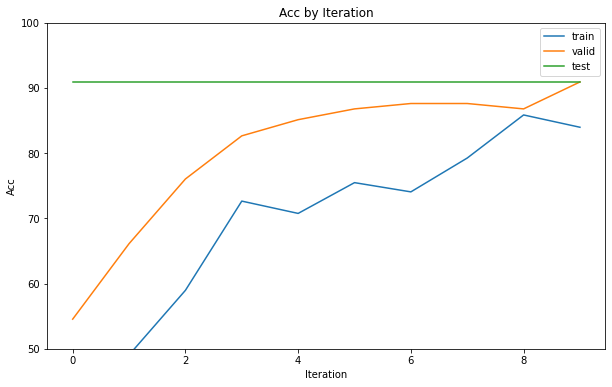

In [25]:
plot_acc(train_acc_h,val_acc_h, test_acc)

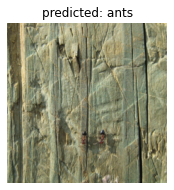

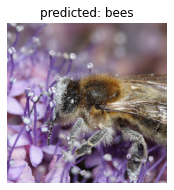

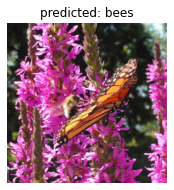

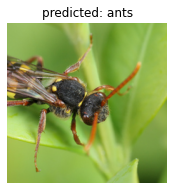

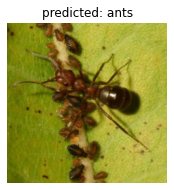

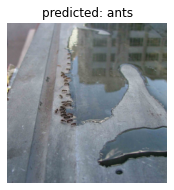

In [26]:
visualize_model(model_conv)

plt.ioff()
plt.show()

# Then finetuning the entire network


In [27]:
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = True


# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv_2 = optim.SGD(model_conv.fc.parameters(), lr=0.00001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler_2 = lr_scheduler.StepLR(optimizer_conv_2, step_size=7, gamma=0.1)

In [28]:
model_conv, val_acc_h, train_acc_h, test_acc = train_model(model_conv, criterion, optimizer_conv_2,
                         exp_lr_scheduler_2, num_epochs=10)

Epoch 0/9 LR 0.000010
----------


train Loss: 9.7513 Acc: 0.0000
val Loss: 13.4609 Acc: 0.0000
Test started
Epoch 1/9 LR 0.000010
----------
train Loss: 9.7410 Acc: 0.0047
val Loss: 11.8467 Acc: 0.0000
Test started
Epoch 2/9 LR 0.000010
----------
train Loss: 9.7428 Acc: 0.0000
val Loss: 11.0642 Acc: 0.0000
Test started
Epoch 3/9 LR 0.000010
----------
train Loss: 9.6140 Acc: 0.0094
val Loss: 10.4763 Acc: 0.0000
Test started
Epoch 4/9 LR 0.000010
----------
train Loss: 9.4791 Acc: 0.0047
val Loss: 10.1678 Acc: 0.0000
Test started
Epoch 5/9 LR 0.000010
----------
train Loss: 9.3917 Acc: 0.0000
val Loss: 9.9770 Acc: 0.0000
Test started
Epoch 6/9 LR 0.000010
----------
train Loss: 9.3988 Acc: 0.0047
val Loss: 9.8037 Acc: 0.0000
Test started
Epoch 7/9 LR 0.000001
----------
train Loss: 9.2765 Acc: 0.0000
val Loss: 9.7795 Acc: 0.0000
Test started
Epoch 8/9 LR 0.000001
----------
train Loss: 9.3474 Acc: 0.0047
val Loss: 9.7739 Acc: 0.0000
Test started
Epoch 9/9 LR 0.000001
----------
train Loss: 9.2854 Acc: 0.0142
val Loss: 

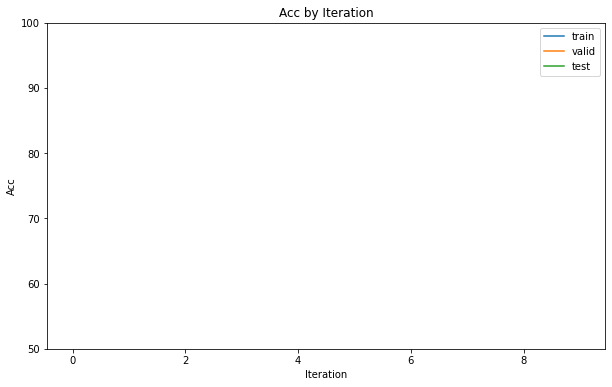

In [29]:
plot_acc(train_acc_h,val_acc_h, test_acc)

IndexError: list index out of range

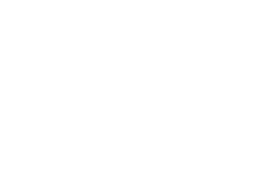

In [30]:
visualize_model(model_conv)

plt.ioff()
plt.show()

<div style="text-align: right">This lab is an extended version of Sasank Chilamkurthy's Pytorch: Transfer Learning for Computer Vision Tutorial.</div>